# Notebook 05: Seeded SHAP Explanations

This notebook generates SHAP explanations for the seeded dry bean classification experiment.

It uses the fixed train/test split from preprocessing and explains the same selected test samples across all seeds and all models.

## Cell 1: Imports and configuration

In [1]:
from pathlib import Path
from itertools import combinations
import json
import math
import pickle
import random
import subprocess
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

NOTEBOOK_NAME = "05_shap_explanations"

SEEDS = list(range(1, 11))
PRIMARY_SEED = 1

MODEL_NAMES = [
    "logistic_regression",
    "decision_tree",
    "random_forest",
    "mlp"
]

MODEL_DISPLAY_NAMES = {
    "logistic_regression": "Logistic Regression",
    "decision_tree": "Decision Tree",
    "random_forest": "Random Forest",
    "mlp": "MLP"
}

MODEL_INPUT_TYPES = {
    "logistic_regression": "scaled",
    "decision_tree": "unscaled",
    "random_forest": "unscaled",
    "mlp": "scaled"
}

MODEL_EXPLAINER_TYPES = {
    "logistic_regression": "linear",
    "decision_tree": "tree",
    "random_forest": "tree",
    "mlp": "kernel"
}

FORCE_RECOMPUTE_SHAP = False
FORCE_RESELECT_SAMPLES = True

N_SAMPLES_PER_GROUP = 3
MAX_TOTAL_SELECTED_SAMPLES = 40

SHAP_BACKGROUND_SIZE_TREE = 100
SHAP_BACKGROUND_SIZE_LINEAR = 100
SHAP_BACKGROUND_SIZE_MLP = 50

MLP_KERNEL_NSAMPLES = 100
TOP_K_LOCAL_FEATURES = 5
TOP_K_GLOBAL_STABILITY = 10

MAKE_PRIMARY_SEED_SUMMARY_PLOTS = True


def find_project_root() -> Path:
    current_path = Path.cwd().resolve()

    if current_path.name == "notebooks":
        return current_path.parent

    if (current_path / "data").exists():
        return current_path

    for parent in current_path.parents:
        if (parent / "data").exists():
            return parent

    return current_path


PROJECT_ROOT = find_project_root()

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
CONFIGS_DIR = PROJECT_ROOT / "configs"

TRAINING_RESULTS_DIR = PROJECT_ROOT / "results" / "03_model_training"
EVALUATION_RESULTS_DIR = PROJECT_ROOT / "results" / "04_model_evaluation"

RESULTS_DIR = PROJECT_ROOT / "results" / NOTEBOOK_NAME
PLOTS_DIR = PROJECT_ROOT / "plots" / NOTEBOOK_NAME

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Training results directory: {TRAINING_RESULTS_DIR}")
print(f"Evaluation results directory: {EVALUATION_RESULTS_DIR}")
print(f"SHAP results directory: {RESULTS_DIR}")
print(f"SHAP plots directory: {PLOTS_DIR}")
print(f"Seeds: {SEEDS}")
print(f"Primary seed for sample selection: {PRIMARY_SEED}")

Project root: G:\Programming\xai
Training results directory: G:\Programming\xai\results\03_model_training
Evaluation results directory: G:\Programming\xai\results\04_model_evaluation
SHAP results directory: G:\Programming\xai\results\05_shap_explanations
SHAP plots directory: G:\Programming\xai\plots\05_shap_explanations
Seeds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Primary seed for sample selection: 1


In [2]:
try:
    import shap
    print(f"SHAP installed. Version: {shap.__version__}")
except ImportError:
    print("SHAP is not installed. Installing SHAP now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap
    print(f"SHAP installed successfully. Version: {shap.__version__}")

SHAP is not installed. Installing SHAP now...
SHAP installed successfully. Version: 0.52.0


## Cell 2: Utility functions

In [3]:
def make_json_serializable(obj):
    if obj is None:
        return None

    if isinstance(obj, Path):
        return str(obj)

    if isinstance(obj, (np.integer,)):
        return int(obj)

    if isinstance(obj, (np.floating,)):
        value = float(obj)
        if math.isnan(value) or math.isinf(value):
            return None
        return value

    if isinstance(obj, (np.ndarray,)):
        return make_json_serializable(obj.tolist())

    if isinstance(obj, pd.DataFrame):
        return make_json_serializable(obj.to_dict(orient="records"))

    if isinstance(obj, pd.Series):
        return make_json_serializable(obj.tolist())

    if isinstance(obj, dict):
        return {
            str(make_json_serializable(key)): make_json_serializable(value)
            for key, value in obj.items()
        }

    if isinstance(obj, (list, tuple, set)):
        return [make_json_serializable(value) for value in obj]

    if isinstance(obj, float):
        if math.isnan(obj) or math.isinf(obj):
            return None
        return obj

    return obj


def load_json(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing JSON file: {path}")

    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)


def save_json(data, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as file:
        json.dump(make_json_serializable(data), file, indent=4)


def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing CSV file: {path}")

    return pd.read_csv(path)


def save_csv(dataframe: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    dataframe.to_csv(path, index=False)


def load_model(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing model file: {path}")

    return joblib.load(path)


def save_pickle(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "wb") as file:
        pickle.dump(obj, file, protocol=pickle.HIGHEST_PROTOCOL)


def load_pickle(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing pickle file: {path}")

    with open(path, "rb") as file:
        return pickle.load(file)


def safe_float(value):
    if pd.isna(value):
        return None
    return float(value)


def safe_int(value):
    if pd.isna(value):
        return None
    return int(value)

## Cell 3: Load processed data and metadata

In [4]:
feature_columns_raw = load_json(DATA_PROCESSED_DIR / "feature_columns.json")

if isinstance(feature_columns_raw, dict) and "feature_columns" in feature_columns_raw:
    feature_columns = feature_columns_raw["feature_columns"]
elif isinstance(feature_columns_raw, list):
    feature_columns = feature_columns_raw
else:
    raise ValueError(
        "feature_columns.json must be a list or a dictionary with key 'feature_columns'."
    )

X_train = load_csv(DATA_PROCESSED_DIR / "X_train.csv")
X_test = load_csv(DATA_PROCESSED_DIR / "X_test.csv")
X_train_scaled = load_csv(DATA_PROCESSED_DIR / "X_train_scaled.csv")
X_test_scaled = load_csv(DATA_PROCESSED_DIR / "X_test_scaled.csv")

y_train_full = load_csv(DATA_PROCESSED_DIR / "y_train.csv")
y_test_full = load_csv(DATA_PROCESSED_DIR / "y_test.csv")

TARGET_COLUMN = "Class_encoded"

if TARGET_COLUMN not in y_train_full.columns:
    raise ValueError(f"{TARGET_COLUMN} not found in y_train.csv")

if TARGET_COLUMN not in y_test_full.columns:
    raise ValueError(f"{TARGET_COLUMN} not found in y_test.csv")

if "sample_id" not in y_train_full.columns:
    raise ValueError("sample_id not found in y_train.csv")

if "sample_id" not in y_test_full.columns:
    raise ValueError("sample_id not found in y_test.csv")

y_train = y_train_full[TARGET_COLUMN].reset_index(drop=True)
y_test = y_test_full[TARGET_COLUMN].reset_index(drop=True)

train_sample_ids = y_train_full["sample_id"].reset_index(drop=True)
test_sample_ids = y_test_full["sample_id"].reset_index(drop=True)

CLASS_ID_TO_NAME = {
    0: "BARBUNYA",
    1: "BOMBAY",
    2: "CALI",
    3: "DERMASON",
    4: "HOROZ",
    5: "SEKER",
    6: "SIRA"
}

CLASS_NAME_TO_ID = {
    class_name: class_id
    for class_id, class_name in CLASS_ID_TO_NAME.items()
}

print("Data loaded successfully.")
print(f"Number of feature columns: {len(feature_columns)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data loaded successfully.
Number of feature columns: 16
X_train shape: (10834, 16)
X_test shape: (2709, 16)
X_train_scaled shape: (10834, 16)
X_test_scaled shape: (2709, 16)
y_train shape: (10834,)
y_test shape: (2709,)


In [5]:
def validate_feature_columns(dataframe: pd.DataFrame, dataframe_name: str, expected_columns: list):
    actual_columns = list(dataframe.columns)

    if actual_columns != expected_columns:
        missing_columns = sorted(set(expected_columns).difference(actual_columns))
        extra_columns = sorted(set(actual_columns).difference(expected_columns))

        print(f"\nColumn validation failed for {dataframe_name}")
        print(f"Missing columns: {missing_columns}")
        print(f"Extra columns: {extra_columns}")

        raise ValueError(f"{dataframe_name} columns do not match feature_columns.json")

    print(f"{dataframe_name}: feature columns OK")


for dataframe, dataframe_name in [
    (X_train, "X_train"),
    (X_test, "X_test"),
    (X_train_scaled, "X_train_scaled"),
    (X_test_scaled, "X_test_scaled")
]:
    validate_feature_columns(dataframe, dataframe_name, feature_columns)

if len(X_test) != len(y_test):
    raise ValueError("X_test and y_test have different row counts.")

if len(X_test_scaled) != len(y_test):
    raise ValueError("X_test_scaled and y_test have different row counts.")

print("\nAll processed data validation checks passed.")

X_train: feature columns OK
X_test: feature columns OK
X_train_scaled: feature columns OK
X_test_scaled: feature columns OK

All processed data validation checks passed.


## Cell 4: Load seeded predictions

In [6]:
def convert_prediction_label_columns(predictions_df: pd.DataFrame) -> pd.DataFrame:
    predictions_df = predictions_df.copy()

    for column in ["seed", "true_label", "predicted_label"]:
        if column in predictions_df.columns:
            converted = pd.to_numeric(predictions_df[column], errors="coerce")
            if converted.notna().all():
                predictions_df[column] = converted.astype(int)

    return predictions_df


def load_seeded_predictions(training_results_dir: Path, seeds: list[int], model_names: list[str]) -> pd.DataFrame:
    combined_predictions_path = training_results_dir / "all_seed_predictions.csv"

    if combined_predictions_path.exists():
        predictions_df = pd.read_csv(combined_predictions_path)
        print(f"Loaded combined predictions: {combined_predictions_path}")

    else:
        print("Combined predictions not found. Loading per-seed prediction files.")
        prediction_frames = []

        for seed in seeds:
            seed_dir = training_results_dir / f"seed_{seed}"

            for model_name in model_names:
                prediction_path = seed_dir / f"{model_name}_predictions.csv"

                if not prediction_path.exists():
                    raise FileNotFoundError(f"Missing prediction file: {prediction_path}")

                model_predictions = pd.read_csv(prediction_path)

                if "seed" not in model_predictions.columns:
                    model_predictions.insert(0, "seed", seed)

                if "model_name" not in model_predictions.columns:
                    model_predictions.insert(1, "model_name", model_name)

                prediction_frames.append(model_predictions)

        predictions_df = pd.concat(prediction_frames, ignore_index=True)

    required_columns = {
        "seed",
        "model_name",
        "sample_id",
        "true_label",
        "predicted_label"
    }

    missing_columns = required_columns.difference(predictions_df.columns)

    if missing_columns:
        raise ValueError(
            f"Predictions are missing required columns: {sorted(missing_columns)}"
        )

    predictions_df = convert_prediction_label_columns(predictions_df)

    expected_runs = len(seeds) * len(model_names)
    actual_runs = predictions_df[["seed", "model_name"]].drop_duplicates().shape[0]

    if actual_runs != expected_runs:
        print(f"Warning: expected {expected_runs} seed-model runs, found {actual_runs}.")

    missing_runs = []

    for seed in seeds:
        for model_name in model_names:
            run_count = len(
                predictions_df[
                    (predictions_df["seed"] == seed)
                    & (predictions_df["model_name"] == model_name)
                ]
            )

            if run_count == 0:
                missing_runs.append((seed, model_name))
            elif run_count != len(X_test):
                raise ValueError(
                    f"Prediction row count mismatch for seed={seed}, model={model_name}. "
                    f"Expected {len(X_test)}, found {run_count}."
                )

    if missing_runs:
        raise ValueError(f"Missing prediction runs: {missing_runs}")

    return predictions_df


predictions_df = load_seeded_predictions(
    training_results_dir=TRAINING_RESULTS_DIR,
    seeds=SEEDS,
    model_names=MODEL_NAMES
)

print("Seeded predictions loaded successfully.")
print(predictions_df.shape)
display(predictions_df.head())

Loaded combined predictions: G:\Programming\xai\results\03_model_training\all_seed_predictions.csv
Seeded predictions loaded successfully.
(108360, 5)


,seed,model_name,sample_id,true_label,predicted_label
0,1,logistic_regression,1223,5,5
1,1,logistic_regression,11769,3,3
2,1,logistic_regression,12059,3,3
3,1,logistic_regression,7126,4,4
4,1,logistic_regression,638,5,5


## Cell 5: Load optional evaluation outputs

In [7]:
evaluation_metrics_path = EVALUATION_RESULTS_DIR / "evaluation_metrics_all_seeds.csv"
evaluation_summary_path = EVALUATION_RESULTS_DIR / "evaluation_summary_mean_std.csv"

evaluation_metrics = None
evaluation_summary = None

if evaluation_metrics_path.exists():
    evaluation_metrics = load_csv(evaluation_metrics_path)
    print(f"Loaded evaluation metrics: {evaluation_metrics_path}")
    display(evaluation_metrics.head())
else:
    print(f"Evaluation metrics file not found yet: {evaluation_metrics_path}")

if evaluation_summary_path.exists():
    evaluation_summary = load_csv(evaluation_summary_path)
    print(f"Loaded evaluation summary: {evaluation_summary_path}")
    display(evaluation_summary)
else:
    print(f"Evaluation summary file not found yet: {evaluation_summary_path}")

Loaded evaluation metrics: G:\Programming\xai\results\04_model_evaluation\evaluation_metrics_all_seeds.csv


,seed,model_name,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,1,decision_tree,0.897010,0.910649,0.912425,0.911434,0.896881
1,2,decision_tree,0.895533,0.910699,0.911309,0.910863,0.895245
2,3,decision_tree,0.894795,0.910368,0.911578,0.910924,0.894677
3,4,decision_tree,0.897010,0.912000,0.913084,0.912404,0.896559
4,5,decision_tree,0.896641,0.911548,0.912306,0.911826,0.896496


Loaded evaluation summary: G:\Programming\xai\results\04_model_evaluation\evaluation_summary_mean_std.csv


,model_name,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,precision_macro_mean,precision_macro_std,precision_macro_min,precision_macro_max,recall_macro_mean,...,recall_macro_min,recall_macro_max,f1_macro_mean,f1_macro_std,f1_macro_min,f1_macro_max,f1_weighted_mean,f1_weighted_std,f1_weighted_min,f1_weighted_max
0,mlp,0.924216,0.003242,0.916574,0.927649,0.935156,0.002383,0.929258,0.938024,0.934041,...,0.929051,0.937896,0.934460,0.002526,0.928943,0.937940,0.924218,0.003219,0.916855,0.927581
1,logistic_regression,0.919158,0.000000,0.919158,0.919158,0.930725,0.000000,0.930725,0.930725,0.930049,...,0.930049,0.930049,0.930237,0.000000,0.930237,0.930237,0.919290,0.000000,0.919290,0.919290
2,random_forest,0.918346,0.001125,0.916205,0.919897,0.931108,0.000974,0.928920,0.932359,0.929101,...,0.927276,0.930646,0.930007,0.000963,0.927974,0.931420,0.918234,0.001127,0.916049,0.919774
3,decision_tree,0.896493,0.001698,0.894795,0.899963,0.911348,0.001305,0.909547,0.913602,0.912330,...,0.911149,0.914281,0.911737,0.001214,0.910350,0.913839,0.896281,0.001672,0.894621,0.899708


## Cell 6: Select fixed samples for SHAP explanation

The sample set is selected once from the primary seed predictions and then reused for every seed. This keeps explanation stability comparisons fair.

In [8]:
test_reference = pd.DataFrame({
    "row_index": np.arange(len(X_test)),
    "sample_id": test_sample_ids,
    "true_label": y_test
})

test_reference["sample_id_key"] = test_reference["sample_id"].astype(str)
test_reference["true_class_name"] = test_reference["true_label"].map(CLASS_ID_TO_NAME)

primary_predictions = predictions_df[predictions_df["seed"] == PRIMARY_SEED].copy()

if primary_predictions.empty:
    raise ValueError(f"No predictions found for PRIMARY_SEED={PRIMARY_SEED}")

primary_prediction_data = {
    model_name: primary_predictions[primary_predictions["model_name"] == model_name].copy()
    for model_name in MODEL_NAMES
}

for model_name, prediction_df in primary_prediction_data.items():
    if len(prediction_df) != len(X_test):
        raise ValueError(
            f"Primary seed prediction count mismatch for {model_name}: "
            f"expected {len(X_test)}, found {len(prediction_df)}"
        )

print("Primary seed prediction data prepared.")

Primary seed prediction data prepared.


In [9]:
def select_correct_samples(
    prediction_df: pd.DataFrame,
    model_name: str,
    class_id: int,
    group_name: str,
    n_samples: int,
    random_state: int = RANDOM_STATE
) -> pd.DataFrame:
    group_df = prediction_df[
        (prediction_df["true_label"] == class_id)
        & (prediction_df["predicted_label"] == class_id)
    ].copy()

    if group_df.empty:
        return pd.DataFrame()

    selected_df = group_df.sample(
        n=min(n_samples, len(group_df)),
        random_state=random_state
    )

    selected_df["selected_from_model"] = model_name
    selected_df["selection_group"] = group_name
    selected_df["selection_seed"] = PRIMARY_SEED

    return selected_df


def select_misclassified_samples(
    prediction_df: pd.DataFrame,
    model_name: str,
    true_class_id: int,
    predicted_class_id: int,
    group_name: str,
    n_samples: int,
    random_state: int = RANDOM_STATE
) -> pd.DataFrame:
    group_df = prediction_df[
        (prediction_df["true_label"] == true_class_id)
        & (prediction_df["predicted_label"] == predicted_class_id)
    ].copy()

    if group_df.empty:
        return pd.DataFrame()

    selected_df = group_df.sample(
        n=min(n_samples, len(group_df)),
        random_state=random_state
    )

    selected_df["selected_from_model"] = model_name
    selected_df["selection_group"] = group_name
    selected_df["selection_seed"] = PRIMARY_SEED

    return selected_df


selected_samples_path = RESULTS_DIR / "selected_samples.csv"

selected_sample_groups = []

for model_name, prediction_df in primary_prediction_data.items():
    selected_sample_groups.extend([
        select_correct_samples(
            prediction_df=prediction_df,
            model_name=model_name,
            class_id=CLASS_NAME_TO_ID["DERMASON"],
            group_name="correct_dermason",
            n_samples=N_SAMPLES_PER_GROUP
        ),
        select_correct_samples(
            prediction_df=prediction_df,
            model_name=model_name,
            class_id=CLASS_NAME_TO_ID["SIRA"],
            group_name="correct_sira",
            n_samples=N_SAMPLES_PER_GROUP
        ),
        select_misclassified_samples(
            prediction_df=prediction_df,
            model_name=model_name,
            true_class_id=CLASS_NAME_TO_ID["DERMASON"],
            predicted_class_id=CLASS_NAME_TO_ID["SIRA"],
            group_name="dermason_predicted_as_sira",
            n_samples=N_SAMPLES_PER_GROUP
        ),
        select_misclassified_samples(
            prediction_df=prediction_df,
            model_name=model_name,
            true_class_id=CLASS_NAME_TO_ID["SIRA"],
            predicted_class_id=CLASS_NAME_TO_ID["DERMASON"],
            group_name="sira_predicted_as_dermason",
            n_samples=N_SAMPLES_PER_GROUP
        ),
        select_correct_samples(
            prediction_df=prediction_df,
            model_name=model_name,
            class_id=CLASS_NAME_TO_ID["BOMBAY"],
            group_name="correct_bombay",
            n_samples=N_SAMPLES_PER_GROUP
        ),
        select_misclassified_samples(
            prediction_df=prediction_df,
            model_name=model_name,
            true_class_id=CLASS_NAME_TO_ID["BARBUNYA"],
            predicted_class_id=CLASS_NAME_TO_ID["CALI"],
            group_name="barbunya_predicted_as_cali",
            n_samples=N_SAMPLES_PER_GROUP
        )
    ])

selected_sample_groups = [
    group_df for group_df in selected_sample_groups
    if not group_df.empty
]

if not selected_sample_groups:
    raise ValueError("No samples were selected for SHAP explanations.")

selected_samples_raw = pd.concat(selected_sample_groups, ignore_index=True)
selected_samples_raw["sample_id_key"] = selected_samples_raw["sample_id"].astype(str)

selected_samples = (
    selected_samples_raw
    .merge(
        test_reference[["row_index", "sample_id_key"]],
        on="sample_id_key",
        how="left"
    )
    .drop(columns=["sample_id_key"])
    .drop_duplicates(subset=["sample_id"])
    .sort_values(by=["selection_group", "sample_id"])
    .reset_index(drop=True)
)

if selected_samples["row_index"].isna().any():
    missing_samples = selected_samples[selected_samples["row_index"].isna()]["sample_id"].tolist()
    raise ValueError(f"Some selected samples were not found in X_test: {missing_samples}")

if len(selected_samples) > MAX_TOTAL_SELECTED_SAMPLES:
    selected_samples = (
        selected_samples
        .sample(n=MAX_TOTAL_SELECTED_SAMPLES, random_state=RANDOM_STATE)
        .sort_values(by=["selection_group", "sample_id"])
        .reset_index(drop=True)
    )

selected_samples["row_index"] = selected_samples["row_index"].astype(int)
selected_samples["true_label"] = selected_samples["true_label"].astype(int)
selected_samples["predicted_label"] = selected_samples["predicted_label"].astype(int)
selected_samples["true_class_name"] = selected_samples["true_label"].map(CLASS_ID_TO_NAME)
selected_samples["predicted_class_name_in_source_model"] = selected_samples["predicted_label"].map(CLASS_ID_TO_NAME)

selected_samples = selected_samples[
    [
        "sample_id",
        "row_index",
        "selection_seed",
        "selected_from_model",
        "selection_group",
        "true_label",
        "true_class_name",
        "predicted_label",
        "predicted_class_name_in_source_model"
    ]
]

save_csv(selected_samples, selected_samples_path)

print(f"Selected samples saved to: {selected_samples_path}")
print(f"Number of selected unique samples: {len(selected_samples)}")
print("\nSelected sample groups:")
display(selected_samples["selection_group"].value_counts().rename_axis("selection_group").reset_index(name="count"))
display(selected_samples.head(20))

Selected samples saved to: G:\Programming\xai\results\05_shap_explanations\selected_samples.csv
Number of selected unique samples: 40

Selected sample groups:


,selection_group,count
0,correct_sira,8
1,dermason_predicted_as_sira,8
2,sira_predicted_as_dermason,8
3,barbunya_predicted_as_cali,7
4,correct_dermason,7
5,correct_bombay,2


,sample_id,row_index,selection_seed,selected_from_model,selection_group,true_label,true_class_name,predicted_label,predicted_class_name_in_source_model
0,2573,192,1,decision_tree,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
1,2590,960,1,decision_tree,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
2,2591,66,1,logistic_regression,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
3,2668,479,1,random_forest,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
4,2790,126,1,logistic_regression,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
5,2883,553,1,mlp,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
6,3330,895,1,logistic_regression,barbunya_predicted_as_cali,0,BARBUNYA,2,CALI
7,3750,1642,1,logistic_regression,correct_bombay,1,BOMBAY,1,BOMBAY
8,3869,806,1,logistic_regression,correct_bombay,1,BOMBAY,1,BOMBAY
9,10986,2688,1,decision_tree,correct_dermason,3,DERMASON,3,DERMASON


## Cell 7: Prepare model input data

In [10]:
selected_row_indices = selected_samples["row_index"].astype(int).tolist()

X_explain_unscaled = X_test.iloc[selected_row_indices].reset_index(drop=True)
X_explain_scaled = X_test_scaled.iloc[selected_row_indices].reset_index(drop=True)

X_background_unscaled = X_train.sample(
    n=min(SHAP_BACKGROUND_SIZE_TREE, len(X_train)),
    random_state=RANDOM_STATE
).reset_index(drop=True)

X_background_scaled_linear = X_train_scaled.sample(
    n=min(SHAP_BACKGROUND_SIZE_LINEAR, len(X_train_scaled)),
    random_state=RANDOM_STATE
).reset_index(drop=True)

X_background_scaled_mlp = X_train_scaled.sample(
    n=min(SHAP_BACKGROUND_SIZE_MLP, len(X_train_scaled)),
    random_state=RANDOM_STATE
).reset_index(drop=True)

model_input_data = {
    "logistic_regression": {
        "X_explain": X_explain_scaled,
        "X_background": X_background_scaled_linear,
        "input_type": "scaled"
    },
    "decision_tree": {
        "X_explain": X_explain_unscaled,
        "X_background": X_background_unscaled,
        "input_type": "unscaled"
    },
    "random_forest": {
        "X_explain": X_explain_unscaled,
        "X_background": X_background_unscaled,
        "input_type": "unscaled"
    },
    "mlp": {
        "X_explain": X_explain_scaled,
        "X_background": X_background_scaled_mlp,
        "input_type": "scaled"
    }
}

print("Model input data prepared.")

for model_name, data_info in model_input_data.items():
    print(
        f"{model_name}: X_explain={data_info['X_explain'].shape}, "
        f"X_background={data_info['X_background'].shape}, "
        f"input_type={data_info['input_type']}"
    )

Model input data prepared.
logistic_regression: X_explain=(40, 16), X_background=(100, 16), input_type=scaled
decision_tree: X_explain=(40, 16), X_background=(100, 16), input_type=unscaled
random_forest: X_explain=(40, 16), X_background=(100, 16), input_type=unscaled
mlp: X_explain=(40, 16), X_background=(50, 16), input_type=scaled


## Cell 8: Load seeded models

In [11]:
def load_seeded_models(seeds: list[int], model_names: list[str]) -> dict:
    loaded_models = {}

    for seed in seeds:
        loaded_models[seed] = {}

        for model_name in model_names:
            model_path = MODELS_DIR / f"seed_{seed}" / f"{model_name}.pkl"
            loaded_models[seed][model_name] = load_model(model_path)

        print(f"Loaded models for seed {seed}")

    return loaded_models


seeded_models = load_seeded_models(SEEDS, MODEL_NAMES)

print("\nAll seeded models loaded successfully.")

Loaded models for seed 1
Loaded models for seed 2
Loaded models for seed 3
Loaded models for seed 4
Loaded models for seed 5
Loaded models for seed 6
Loaded models for seed 7
Loaded models for seed 8
Loaded models for seed 9
Loaded models for seed 10

All seeded models loaded successfully.


## Cell 9: SHAP computation functions

In [12]:
def normalize_shap_values(shap_output, n_samples: int, n_features: int) -> np.ndarray:
    if hasattr(shap_output, "values"):
        values = shap_output.values
    else:
        values = shap_output

    if isinstance(values, list):
        values = np.stack(values, axis=2)

    values = np.asarray(values)

    if values.ndim == 2:
        values = values[:, :, np.newaxis]

    if values.ndim == 3:
        if values.shape[0] == n_samples and values.shape[1] == n_features:
            return values

        if values.shape[1] == n_samples and values.shape[2] == n_features:
            return np.transpose(values, (1, 2, 0))

    raise ValueError(
        "Unexpected SHAP value shape. "
        f"Got {values.shape}, expected ({n_samples}, {n_features}, n_outputs)."
    )


def compute_tree_shap_values(model, X_explain: pd.DataFrame):
    explainer = shap.TreeExplainer(model)

    try:
        shap_output = explainer(X_explain, check_additivity=False)
    except Exception:
        shap_output = explainer.shap_values(X_explain, check_additivity=False)

    shap_values = normalize_shap_values(
        shap_output,
        n_samples=len(X_explain),
        n_features=len(feature_columns)
    )

    return shap_values


def compute_linear_shap_values(model, X_background: pd.DataFrame, X_explain: pd.DataFrame):
    try:
        explainer = shap.LinearExplainer(model, X_background)
        shap_output = explainer(X_explain)
    except Exception:
        explainer = shap.Explainer(model.predict_proba, X_background)
        shap_output = explainer(X_explain)

    shap_values = normalize_shap_values(
        shap_output,
        n_samples=len(X_explain),
        n_features=len(feature_columns)
    )

    return shap_values


def compute_kernel_shap_values(
    model,
    X_background: pd.DataFrame,
    X_explain: pd.DataFrame,
    nsamples: int
):
    explainer = shap.KernelExplainer(model.predict_proba, X_background)

    shap_output = explainer.shap_values(
        X_explain,
        nsamples=nsamples
    )

    shap_values = normalize_shap_values(
        shap_output,
        n_samples=len(X_explain),
        n_features=len(feature_columns)
    )

    return shap_values


def get_predictions_for_selected_samples(seed: int, model_name: str) -> pd.DataFrame:
    prediction_df = predictions_df[
        (predictions_df["seed"] == seed)
        & (predictions_df["model_name"] == model_name)
    ].copy()

    if prediction_df.empty:
        raise ValueError(f"No predictions found for seed={seed}, model={model_name}")

    prediction_df["sample_id_key"] = prediction_df["sample_id"].astype(str)

    selected_predictions = (
        selected_samples[["sample_id"]]
        .assign(sample_id_key=lambda df: df["sample_id"].astype(str))
        .merge(
            prediction_df[["sample_id_key", "predicted_label", "true_label"]],
            on="sample_id_key",
            how="left"
        )
        .drop(columns=["sample_id_key"])
    )

    if selected_predictions["predicted_label"].isna().any():
        missing_ids = selected_predictions[
            selected_predictions["predicted_label"].isna()
        ]["sample_id"].tolist()
        raise ValueError(
            f"Missing selected sample predictions for seed={seed}, model={model_name}: {missing_ids}"
        )

    selected_predictions["predicted_label"] = selected_predictions["predicted_label"].astype(int)
    selected_predictions["true_label"] = selected_predictions["true_label"].astype(int)

    return selected_predictions


def compute_shap_for_model(seed: int, model_name: str, model):
    explainer_type = MODEL_EXPLAINER_TYPES[model_name]

    X_explain_model = model_input_data[model_name]["X_explain"]
    X_background_model = model_input_data[model_name]["X_background"]

    if explainer_type == "tree":
        shap_values = compute_tree_shap_values(
            model=model,
            X_explain=X_explain_model
        )

    elif explainer_type == "linear":
        shap_values = compute_linear_shap_values(
            model=model,
            X_background=X_background_model,
            X_explain=X_explain_model
        )

    elif explainer_type == "kernel":
        shap_values = compute_kernel_shap_values(
            model=model,
            X_background=X_background_model,
            X_explain=X_explain_model,
            nsamples=MLP_KERNEL_NSAMPLES
        )

    else:
        raise ValueError(f"Unknown SHAP explainer type: {explainer_type}")

    selected_predictions = get_predictions_for_selected_samples(
        seed=seed,
        model_name=model_name
    )

    shap_result = {
        "seed": int(seed),
        "model_name": model_name,
        "display_name": MODEL_DISPLAY_NAMES[model_name],
        "explainer_type": explainer_type,
        "input_type": model_input_data[model_name]["input_type"],
        "feature_columns": feature_columns,
        "selected_samples": selected_samples.copy(),
        "predicted_labels": selected_predictions["predicted_label"].astype(int).to_numpy(),
        "true_labels": selected_predictions["true_label"].astype(int).to_numpy(),
        "shap_values": shap_values
    }

    return shap_result

## Cell 10: Compute or load SHAP values for all seeds

In [13]:
shap_results = {}

for seed in SEEDS:
    print("\n" + "=" * 80)
    print(f"SHAP for seed {seed}")
    print("=" * 80)

    seed_results_dir = RESULTS_DIR / f"seed_{seed}"
    seed_results_dir.mkdir(parents=True, exist_ok=True)

    for model_name in MODEL_NAMES:
        shap_values_path = seed_results_dir / f"shap_values_{model_name}.pkl"

        if shap_values_path.exists() and not FORCE_RECOMPUTE_SHAP:
            print(f"Loading saved SHAP values: seed={seed}, model={model_name}")
            shap_result = load_pickle(shap_values_path)

        else:
            print(f"Computing SHAP values: seed={seed}, model={model_name}")

            model = seeded_models[seed][model_name]
            shap_result = compute_shap_for_model(
                seed=seed,
                model_name=model_name,
                model=model
            )

            save_pickle(shap_result, shap_values_path)
            print(f"Saved SHAP values: {shap_values_path}")

        shap_values = shap_result["shap_values"]

        if shap_values.shape[0] != len(selected_samples):
            raise ValueError(
                f"SHAP sample count mismatch for seed={seed}, model={model_name}: "
                f"expected {len(selected_samples)}, got {shap_values.shape[0]}"
            )

        if shap_values.shape[1] != len(feature_columns):
            raise ValueError(
                f"SHAP feature count mismatch for seed={seed}, model={model_name}: "
                f"expected {len(feature_columns)}, got {shap_values.shape[1]}"
            )

        shap_results[(seed, model_name)] = shap_result

        print(f"Shape: {shap_values.shape}")

print("\nSHAP computation/loading finished for all seeded model runs.")
print(f"Total SHAP results: {len(shap_results)}")


SHAP for seed 1
Computing SHAP values: seed=1, model=logistic_regression
Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_1\shap_values_logistic_regression.pkl
Shape: (40, 16, 7)
Computing SHAP values: seed=1, model=decision_tree
Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_1\shap_values_decision_tree.pkl
Shape: (40, 16, 7)
Computing SHAP values: seed=1, model=random_forest
Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_1\shap_values_random_forest.pkl
Shape: (40, 16, 7)
Computing SHAP values: seed=1, model=mlp


  0%|          | 0/40 [00:00<?, ?it/s]

Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_1\shap_values_mlp.pkl
Shape: (40, 16, 7)

SHAP for seed 2
Computing SHAP values: seed=2, model=logistic_regression
Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_2\shap_values_logistic_regression.pkl
Shape: (40, 16, 7)
Computing SHAP values: seed=2, model=decision_tree
Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_2\shap_values_decision_tree.pkl
Shape: (40, 16, 7)
Computing SHAP values: seed=2, model=random_forest
Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_2\shap_values_random_forest.pkl
Shape: (40, 16, 7)
Computing SHAP values: seed=2, model=mlp


  0%|          | 0/40 [00:00<?, ?it/s]

Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_2\shap_values_mlp.pkl
Shape: (40, 16, 7)

SHAP for seed 3
Computing SHAP values: seed=3, model=logistic_regression
Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_3\shap_values_logistic_regression.pkl
Shape: (40, 16, 7)
Computing SHAP values: seed=3, model=decision_tree
Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_3\shap_values_decision_tree.pkl
Shape: (40, 16, 7)
Computing SHAP values: seed=3, model=random_forest
Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_3\shap_values_random_forest.pkl
Shape: (40, 16, 7)
Computing SHAP values: seed=3, model=mlp


...

Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_8\shap_values_mlp.pkl
Shape: (40, 16, 7)

SHAP for seed 9
Computing SHAP values: seed=9, model=logistic_regression
Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_9\shap_values_logistic_regression.pkl
Shape: (40, 16, 7)
Computing SHAP values: seed=9, model=decision_tree
Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_9\shap_values_decision_tree.pkl
Shape: (40, 16, 7)
Computing SHAP values: seed=9, model=random_forest
Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_9\shap_values_random_forest.pkl
Shape: (40, 16, 7)
Computing SHAP values: seed=9, model=mlp


  0%|          | 0/40 [00:00<?, ?it/s]

Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_9\shap_values_mlp.pkl
Shape: (40, 16, 7)

SHAP for seed 10
Computing SHAP values: seed=10, model=logistic_regression
Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_10\shap_values_logistic_regression.pkl
Shape: (40, 16, 7)
Computing SHAP values: seed=10, model=decision_tree
Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_10\shap_values_decision_tree.pkl
Shape: (40, 16, 7)
Computing SHAP values: seed=10, model=random_forest
Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_10\shap_values_random_forest.pkl
Shape: (40, 16, 7)
Computing SHAP values: seed=10, model=mlp


  0%|          | 0/40 [00:00<?, ?it/s]

Saved SHAP values: G:\Programming\xai\results\05_shap_explanations\seed_10\shap_values_mlp.pkl
Shape: (40, 16, 7)

SHAP computation/loading finished for all seeded model runs.
Total SHAP results: 40


## Cell 11: Global SHAP importance across seeds

In [14]:
def calculate_global_shap_importance(shap_result: dict) -> pd.DataFrame:
    shap_values = shap_result["shap_values"]

    mean_abs_shap_all_classes = np.mean(np.abs(shap_values), axis=(0, 2))

    importance_df = pd.DataFrame({
        "seed": int(shap_result["seed"]),
        "model_name": shap_result["model_name"],
        "display_name": shap_result["display_name"],
        "input_type": shap_result["input_type"],
        "explainer_type": shap_result["explainer_type"],
        "feature": feature_columns,
        "mean_abs_shap": mean_abs_shap_all_classes.astype(float)
    })

    importance_df = importance_df.sort_values(
        by="mean_abs_shap",
        ascending=False
    ).reset_index(drop=True)

    importance_df["rank"] = np.arange(1, len(importance_df) + 1)

    return importance_df


global_importance_tables = []

for (seed, model_name), shap_result in shap_results.items():
    importance_df = calculate_global_shap_importance(shap_result)

    seed_results_dir = RESULTS_DIR / f"seed_{seed}"
    importance_path = seed_results_dir / f"shap_feature_importance_{model_name}.csv"
    save_csv(importance_df, importance_path)

    global_importance_tables.append(importance_df)

    print(f"Saved global SHAP importance: {importance_path}")

global_shap_importance = pd.concat(global_importance_tables, ignore_index=True)

global_all_seeds_path = RESULTS_DIR / "shap_feature_importance_all_seeds.csv"
save_csv(global_shap_importance, global_all_seeds_path)

print(f"\nSaved combined global SHAP importance: {global_all_seeds_path}")
display(global_shap_importance.head(20))

Saved global SHAP importance: G:\Programming\xai\results\05_shap_explanations\seed_1\shap_feature_importance_logistic_regression.csv
Saved global SHAP importance: G:\Programming\xai\results\05_shap_explanations\seed_1\shap_feature_importance_decision_tree.csv
Saved global SHAP importance: G:\Programming\xai\results\05_shap_explanations\seed_1\shap_feature_importance_random_forest.csv
Saved global SHAP importance: G:\Programming\xai\results\05_shap_explanations\seed_1\shap_feature_importance_mlp.csv
Saved global SHAP importance: G:\Programming\xai\results\05_shap_explanations\seed_2\shap_feature_importance_logistic_regression.csv
Saved global SHAP importance: G:\Programming\xai\results\05_shap_explanations\seed_2\shap_feature_importance_decision_tree.csv
Saved global SHAP importance: G:\Programming\xai\results\05_shap_explanations\seed_2\shap_feature_importance_random_forest.csv
Saved global SHAP importance: G:\Programming\xai\results\05_shap_explanations\seed_2\shap_feature_importance_

,seed,model_name,display_name,input_type,explainer_type,feature,mean_abs_shap,rank
0,1,logistic_regression,Logistic Regression,scaled,linear,ShapeFactor1,1.463387,1
1,1,logistic_regression,Logistic Regression,scaled,linear,MinorAxisLength,1.094949,2
2,1,logistic_regression,Logistic Regression,scaled,linear,EquivDiameter,0.892912,3
3,1,logistic_regression,Logistic Regression,scaled,linear,Perimeter,0.885555,4
4,1,logistic_regression,Logistic Regression,scaled,linear,ConvexArea,0.796841,5
5,1,logistic_regression,Logistic Regression,scaled,linear,Area,0.778417,6
6,1,logistic_regression,Logistic Regression,scaled,linear,MajorAxisLength,0.774978,7
7,1,logistic_regression,Logistic Regression,scaled,linear,ShapeFactor4,0.733741,8
8,1,logistic_regression,Logistic Regression,scaled,linear,ShapeFactor2,0.610278,9
9,1,logistic_regression,Logistic Regression,scaled,linear,roundness,0.350205,10


In [15]:
global_shap_summary = (
    global_shap_importance
    .groupby(["model_name", "display_name", "input_type", "explainer_type", "feature"], as_index=False)
    .agg(
        mean_abs_shap_mean=("mean_abs_shap", "mean"),
        mean_abs_shap_std=("mean_abs_shap", "std"),
        mean_abs_shap_min=("mean_abs_shap", "min"),
        mean_abs_shap_max=("mean_abs_shap", "max"),
        rank_mean=("rank", "mean"),
        rank_std=("rank", "std"),
        rank_min=("rank", "min"),
        rank_max=("rank", "max"),
        n_seeds=("seed", "nunique")
    )
)

global_shap_summary["rank_mean"] = global_shap_summary["rank_mean"].astype(float)

global_shap_summary = global_shap_summary.sort_values(
    ["model_name", "rank_mean", "mean_abs_shap_mean"],
    ascending=[True, True, False]
).reset_index(drop=True)

global_shap_summary["mean_rank_order"] = (
    global_shap_summary
    .groupby("model_name")["rank_mean"]
    .rank(method="first", ascending=True)
    .astype(int)
)

global_summary_path = RESULTS_DIR / "shap_feature_importance_mean_std_across_seeds.csv"
save_csv(global_shap_summary, global_summary_path)

print(f"Saved global SHAP mean/std summary: {global_summary_path}")
display(global_shap_summary.head(30))

Saved global SHAP mean/std summary: G:\Programming\xai\results\05_shap_explanations\shap_feature_importance_mean_std_across_seeds.csv


,model_name,display_name,input_type,explainer_type,feature,mean_abs_shap_mean,mean_abs_shap_std,mean_abs_shap_min,mean_abs_shap_max,rank_mean,rank_std,rank_min,rank_max,n_seeds,mean_rank_order
0,decision_tree,Decision Tree,unscaled,tree,MajorAxisLength,0.083246,0.001695,0.080029,0.085577,1.0,0.000000,1,1,10,1
1,decision_tree,Decision Tree,unscaled,tree,Perimeter,0.076579,0.001211,0.074431,0.077824,2.0,0.000000,2,2,10,2
2,decision_tree,Decision Tree,unscaled,tree,ShapeFactor1,0.038291,0.005486,0.033896,0.048468,4.4,0.843274,3,5,10,3
3,decision_tree,Decision Tree,unscaled,tree,MinorAxisLength,0.035203,0.005896,0.023567,0.040588,4.8,1.549193,3,8,10,4
4,decision_tree,Decision Tree,unscaled,tree,Compactness,0.034948,0.014736,0.014371,0.055628,5.1,2.131770,3,8,10,5
5,decision_tree,Decision Tree,unscaled,tree,roundness,0.028428,0.000755,0.027407,0.029647,5.8,0.421637,5,6,10,6
6,decision_tree,Decision Tree,unscaled,tree,ShapeFactor3,0.026904,0.014103,0.007811,0.044081,6.2,3.224903,3,11,10,7
7,decision_tree,Decision Tree,unscaled,tree,ShapeFactor4,0.023092,0.001084,0.021702,0.025256,7.3,0.483046,7,8,10,8
8,decision_tree,Decision Tree,unscaled,tree,Solidity,0.012169,0.000589,0.010895,0.013089,8.9,0.567646,8,10,10,9
9,decision_tree,Decision Tree,unscaled,tree,Extent,0.009787,0.000727,0.009151,0.011529,10.1,0.875595,9,11,10,10


## Cell 12: Global explanation stability across seeds

In [16]:
def calculate_rank_stability(global_importance_df: pd.DataFrame, top_k: int = TOP_K_GLOBAL_STABILITY) -> pd.DataFrame:
    stability_rows = []

    for model_name, model_df in global_importance_df.groupby("model_name"):
        seeds_available = sorted(model_df["seed"].unique())

        for seed_a, seed_b in combinations(seeds_available, 2):
            ranks_a = model_df[model_df["seed"] == seed_a][["feature", "rank"]].rename(
                columns={"rank": "rank_a"}
            )
            ranks_b = model_df[model_df["seed"] == seed_b][["feature", "rank"]].rename(
                columns={"rank": "rank_b"}
            )

            merged_ranks = ranks_a.merge(ranks_b, on="feature", how="inner")

            if len(merged_ranks) != len(feature_columns):
                raise ValueError(
                    f"Rank merge mismatch for {model_name}, seeds {seed_a}/{seed_b}."
                )

            spearman_rank_correlation = merged_ranks["rank_a"].corr(
                merged_ranks["rank_b"],
                method="spearman"
            )

            top_features_a = set(
                model_df[
                    (model_df["seed"] == seed_a)
                    & (model_df["rank"] <= top_k)
                ]["feature"]
            )

            top_features_b = set(
                model_df[
                    (model_df["seed"] == seed_b)
                    & (model_df["rank"] <= top_k)
                ]["feature"]
            )

            intersection_count = len(top_features_a.intersection(top_features_b))
            union_count = len(top_features_a.union(top_features_b))

            stability_rows.append({
                "model_name": model_name,
                "display_name": MODEL_DISPLAY_NAMES.get(model_name, model_name),
                "seed_a": int(seed_a),
                "seed_b": int(seed_b),
                "spearman_rank_correlation": safe_float(spearman_rank_correlation),
                "top_k": int(top_k),
                "top_k_overlap_count": int(intersection_count),
                "top_k_overlap_rate": float(intersection_count / top_k),
                "top_k_jaccard": float(intersection_count / union_count) if union_count else None
            })

    return pd.DataFrame(stability_rows)


rank_stability_df = calculate_rank_stability(
    global_importance_df=global_shap_importance,
    top_k=TOP_K_GLOBAL_STABILITY
)

rank_stability_path = RESULTS_DIR / "shap_global_rank_stability_across_seeds.csv"
save_csv(rank_stability_df, rank_stability_path)

rank_stability_summary = (
    rank_stability_df
    .groupby(["model_name", "display_name"], as_index=False)
    .agg(
        spearman_mean=("spearman_rank_correlation", "mean"),
        spearman_std=("spearman_rank_correlation", "std"),
        top_k_overlap_rate_mean=("top_k_overlap_rate", "mean"),
        top_k_overlap_rate_std=("top_k_overlap_rate", "std"),
        top_k_jaccard_mean=("top_k_jaccard", "mean"),
        top_k_jaccard_std=("top_k_jaccard", "std"),
        n_seed_pairs=("seed_a", "count")
    )
    .sort_values("spearman_mean", ascending=False)
    .reset_index(drop=True)
)

rank_stability_summary_path = RESULTS_DIR / "shap_global_rank_stability_summary.csv"
save_csv(rank_stability_summary, rank_stability_summary_path)

print(f"Saved rank stability pairwise file: {rank_stability_path}")
print(f"Saved rank stability summary: {rank_stability_summary_path}")
display(rank_stability_summary)

Saved rank stability pairwise file: G:\Programming\xai\results\05_shap_explanations\shap_global_rank_stability_across_seeds.csv
Saved rank stability summary: G:\Programming\xai\results\05_shap_explanations\shap_global_rank_stability_summary.csv


,model_name,display_name,spearman_mean,spearman_std,top_k_overlap_rate_mean,top_k_overlap_rate_std,top_k_jaccard_mean,top_k_jaccard_std,n_seed_pairs
0,logistic_regression,Logistic Regression,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,45
1,random_forest,Random Forest,0.953072,0.017802,1.000000,0.000000,1.000000,0.000000,45
2,decision_tree,Decision Tree,0.912810,0.051534,0.917778,0.049031,0.851852,0.086007,45
3,mlp,MLP,0.809739,0.105503,0.840000,0.078044,0.731728,0.115748,45


In [17]:
top_feature_frequency_rows = []

for (model_name, feature), group_df in global_shap_importance.groupby(["model_name", "feature"]):
    top_k_count = int((group_df["rank"] <= TOP_K_GLOBAL_STABILITY).sum())

    top_feature_frequency_rows.append({
        "model_name": model_name,
        "display_name": MODEL_DISPLAY_NAMES.get(model_name, model_name),
        "feature": feature,
        "top_k": int(TOP_K_GLOBAL_STABILITY),
        "top_k_count": top_k_count,
        "top_k_frequency": float(top_k_count / len(SEEDS)),
        "rank_mean": float(group_df["rank"].mean()),
        "rank_std": safe_float(group_df["rank"].std()),
        "mean_abs_shap_mean": float(group_df["mean_abs_shap"].mean()),
        "mean_abs_shap_std": safe_float(group_df["mean_abs_shap"].std())
    })

top_feature_frequency_df = pd.DataFrame(top_feature_frequency_rows)
top_feature_frequency_df = top_feature_frequency_df.sort_values(
    ["model_name", "top_k_frequency", "rank_mean"],
    ascending=[True, False, True]
).reset_index(drop=True)

top_feature_frequency_path = RESULTS_DIR / "shap_top_feature_frequency_across_seeds.csv"
save_csv(top_feature_frequency_df, top_feature_frequency_path)

print(f"Saved top feature frequency: {top_feature_frequency_path}")
display(top_feature_frequency_df.head(40))

Saved top feature frequency: G:\Programming\xai\results\05_shap_explanations\shap_top_feature_frequency_across_seeds.csv


,model_name,display_name,feature,top_k,top_k_count,top_k_frequency,rank_mean,rank_std,mean_abs_shap_mean,mean_abs_shap_std
0,decision_tree,Decision Tree,MajorAxisLength,10,10,1.0,1.0,0.000000,0.083246,1.695098e-03
1,decision_tree,Decision Tree,Perimeter,10,10,1.0,2.0,0.000000,0.076579,1.210943e-03
2,decision_tree,Decision Tree,ShapeFactor1,10,10,1.0,4.4,0.843274,0.038291,5.486451e-03
3,decision_tree,Decision Tree,MinorAxisLength,10,10,1.0,4.8,1.549193,0.035203,5.896003e-03
4,decision_tree,Decision Tree,Compactness,10,10,1.0,5.1,2.131770,0.034948,1.473592e-02
5,decision_tree,Decision Tree,roundness,10,10,1.0,5.8,0.421637,0.028428,7.547418e-04
6,decision_tree,Decision Tree,ShapeFactor4,10,10,1.0,7.3,0.483046,0.023092,1.084128e-03
7,decision_tree,Decision Tree,Solidity,10,10,1.0,8.9,0.567646,0.012169,5.891034e-04
8,decision_tree,Decision Tree,ShapeFactor3,10,8,0.8,6.2,3.224903,0.026904,1.410296e-02
9,decision_tree,Decision Tree,Extent,10,6,0.6,10.1,0.875595,0.009787,7.270512e-04


## Cell 13: Local SHAP explanations across seeds

In [18]:
def create_local_explanation_table(
    shap_result: dict,
    top_k: int = TOP_K_LOCAL_FEATURES
) -> pd.DataFrame:
    seed = int(shap_result["seed"])
    model_name = shap_result["model_name"]
    shap_values = shap_result["shap_values"]
    predicted_labels = shap_result["predicted_labels"]
    input_type = shap_result["input_type"]

    X_explain_model = model_input_data[model_name]["X_explain"]

    local_rows = []

    for sample_position in range(len(selected_samples)):
        selected_sample = selected_samples.iloc[sample_position]
        predicted_class_id = int(predicted_labels[sample_position])

        if shap_values.shape[2] == 1:
            class_shap_values = shap_values[sample_position, :, 0]
        else:
            if predicted_class_id >= shap_values.shape[2]:
                raise ValueError(
                    f"Predicted class id {predicted_class_id} is out of bounds "
                    f"for SHAP output axis with size {shap_values.shape[2]}."
                )
            class_shap_values = shap_values[sample_position, :, predicted_class_id]

        top_feature_indices = np.argsort(np.abs(class_shap_values))[::-1][:top_k]

        original_row = X_explain_unscaled.iloc[sample_position]
        model_input_row = X_explain_model.iloc[sample_position]

        for rank, feature_index in enumerate(top_feature_indices, start=1):
            feature_name = feature_columns[feature_index]
            shap_value = float(class_shap_values[feature_index])

            local_rows.append({
                "seed": seed,
                "model_name": model_name,
                "display_name": shap_result["display_name"],
                "input_type": input_type,
                "explainer_type": shap_result["explainer_type"],
                "sample_id": selected_sample["sample_id"],
                "row_index": int(selected_sample["row_index"]),
                "selection_seed": int(selected_sample["selection_seed"]),
                "selection_group": selected_sample["selection_group"],
                "selected_from_model": selected_sample["selected_from_model"],
                "true_label": int(selected_sample["true_label"]),
                "true_class_name": selected_sample["true_class_name"],
                "explained_predicted_label": predicted_class_id,
                "explained_predicted_class_name": CLASS_ID_TO_NAME[predicted_class_id],
                "feature_rank": int(rank),
                "feature": feature_name,
                "shap_value": shap_value,
                "abs_shap_value": abs(shap_value),
                "original_feature_value": safe_float(original_row[feature_name]),
                "model_input_feature_value": safe_float(model_input_row[feature_name])
            })

    return pd.DataFrame(local_rows)


local_explanation_tables = []

for (seed, model_name), shap_result in shap_results.items():
    local_df = create_local_explanation_table(
        shap_result=shap_result,
        top_k=TOP_K_LOCAL_FEATURES
    )

    seed_results_dir = RESULTS_DIR / f"seed_{seed}"
    local_path = seed_results_dir / f"local_shap_explanations_{model_name}.csv"
    save_csv(local_df, local_path)

    local_explanation_tables.append(local_df)

    print(f"Saved local SHAP explanations: {local_path}")

local_shap_explanations = pd.concat(local_explanation_tables, ignore_index=True)

local_all_seeds_path = RESULTS_DIR / "local_shap_explanations_all_seeds.csv"
save_csv(local_shap_explanations, local_all_seeds_path)

print(f"\nSaved combined local SHAP explanations: {local_all_seeds_path}")
display(local_shap_explanations.head(30))

Saved local SHAP explanations: G:\Programming\xai\results\05_shap_explanations\seed_1\local_shap_explanations_logistic_regression.csv
Saved local SHAP explanations: G:\Programming\xai\results\05_shap_explanations\seed_1\local_shap_explanations_decision_tree.csv
Saved local SHAP explanations: G:\Programming\xai\results\05_shap_explanations\seed_1\local_shap_explanations_random_forest.csv
Saved local SHAP explanations: G:\Programming\xai\results\05_shap_explanations\seed_1\local_shap_explanations_mlp.csv
Saved local SHAP explanations: G:\Programming\xai\results\05_shap_explanations\seed_2\local_shap_explanations_logistic_regression.csv
Saved local SHAP explanations: G:\Programming\xai\results\05_shap_explanations\seed_2\local_shap_explanations_decision_tree.csv
Saved local SHAP explanations: G:\Programming\xai\results\05_shap_explanations\seed_2\local_shap_explanations_random_forest.csv
Saved local SHAP explanations: G:\Programming\xai\results\05_shap_explanations\seed_2\local_shap_expla

,seed,model_name,display_name,input_type,explainer_type,sample_id,row_index,selection_seed,selection_group,selected_from_model,true_label,true_class_name,explained_predicted_label,explained_predicted_class_name,feature_rank,feature,shap_value,abs_shap_value,original_feature_value,model_input_feature_value
0,1,logistic_regression,Logistic Regression,scaled,linear,2573,192,1,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,1,ShapeFactor1,2.864522,2.864522,0.005315,-1.105093
1,1,logistic_regression,Logistic Regression,scaled,linear,2573,192,1,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,2,roundness,0.864478,0.864478,0.904533,0.518322
2,1,logistic_regression,Logistic Regression,scaled,linear,2573,192,1,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,3,MinorAxisLength,0.720907,0.720907,240.513029,0.847777
3,1,logistic_regression,Logistic Regression,scaled,linear,2573,192,1,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,4,EquivDiameter,0.711784,0.711784,293.647535,0.686391
4,1,logistic_regression,Logistic Regression,scaled,linear,2573,192,1,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,5,ShapeFactor2,0.638080,0.638080,0.001452,-0.449477
5,1,logistic_regression,Logistic Regression,scaled,linear,2590,960,1,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,1,ShapeFactor1,1.908388,1.908388,0.005690,-0.773087
6,1,logistic_regression,Logistic Regression,scaled,linear,2590,960,1,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,2,ShapeFactor2,1.424755,1.424755,0.001174,-0.916843
7,1,logistic_regression,Logistic Regression,scaled,linear,2590,960,1,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,3,ShapeFactor4,-0.843588,0.843588,0.997570,0.573635
8,1,logistic_regression,Logistic Regression,scaled,linear,2590,960,1,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,4,Eccentricity,0.807930,0.807930,0.814855,0.703244
9,1,logistic_regression,Logistic Regression,scaled,linear,2590,960,1,barbunya_predicted_as_cali,decision_tree,0,BARBUNYA,2,CALI,5,MajorAxisLength,0.791775,0.791775,386.987870,0.783986


## Cell 14: Save primary-seed compatibility files

These files keep the same filenames as the earlier single-run notebook. They are useful if the next LIME/stability notebooks still expect the old filenames.

In [19]:
primary_seed_global = global_shap_importance[
    global_shap_importance["seed"] == PRIMARY_SEED
].copy()

primary_seed_local = local_shap_explanations[
    local_shap_explanations["seed"] == PRIMARY_SEED
].copy()

primary_global_path = RESULTS_DIR / "shap_feature_importance_all_models.csv"
primary_local_path = RESULTS_DIR / "local_shap_explanations_all_models.csv"

save_csv(primary_seed_global, primary_global_path)
save_csv(primary_seed_local, primary_local_path)

for model_name in MODEL_NAMES:
    primary_result = shap_results[(PRIMARY_SEED, model_name)]
    primary_pickle_path = RESULTS_DIR / f"shap_values_{model_name}.pkl"
    save_pickle(primary_result, primary_pickle_path)

    primary_importance = primary_seed_global[
        primary_seed_global["model_name"] == model_name
    ]
    primary_importance_path = RESULTS_DIR / f"shap_feature_importance_{model_name}.csv"
    save_csv(primary_importance, primary_importance_path)

    primary_local = primary_seed_local[
        primary_seed_local["model_name"] == model_name
    ]
    primary_local_model_path = RESULTS_DIR / f"local_shap_explanations_{model_name}.csv"
    save_csv(primary_local, primary_local_model_path)

print(f"Saved primary-seed global compatibility file: {primary_global_path}")
print(f"Saved primary-seed local compatibility file: {primary_local_path}")

Saved primary-seed global compatibility file: G:\Programming\xai\results\05_shap_explanations\shap_feature_importance_all_models.csv
Saved primary-seed local compatibility file: G:\Programming\xai\results\05_shap_explanations\local_shap_explanations_all_models.csv


## Cell 15: Plot global SHAP importance and stability

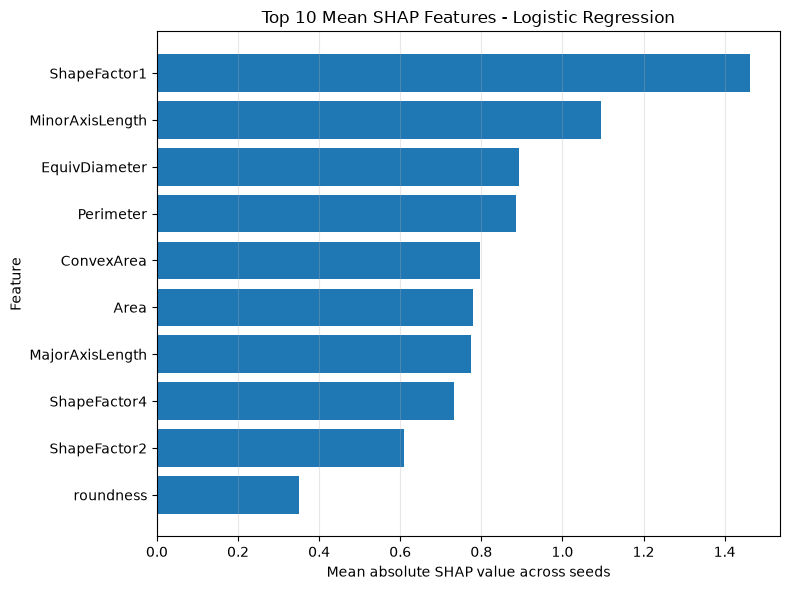

Saved plot: G:\Programming\xai\plots\05_shap_explanations\shap_bar_mean_std_logistic_regression.png


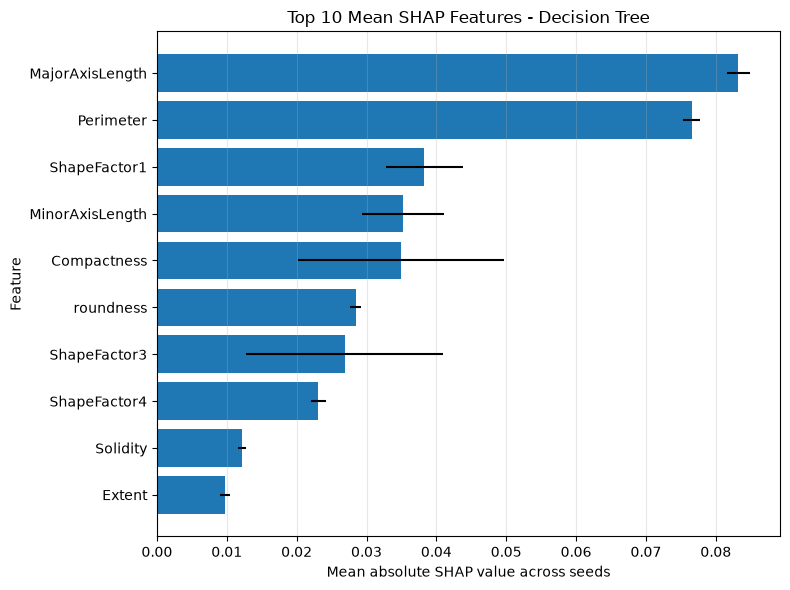

Saved plot: G:\Programming\xai\plots\05_shap_explanations\shap_bar_mean_std_decision_tree.png


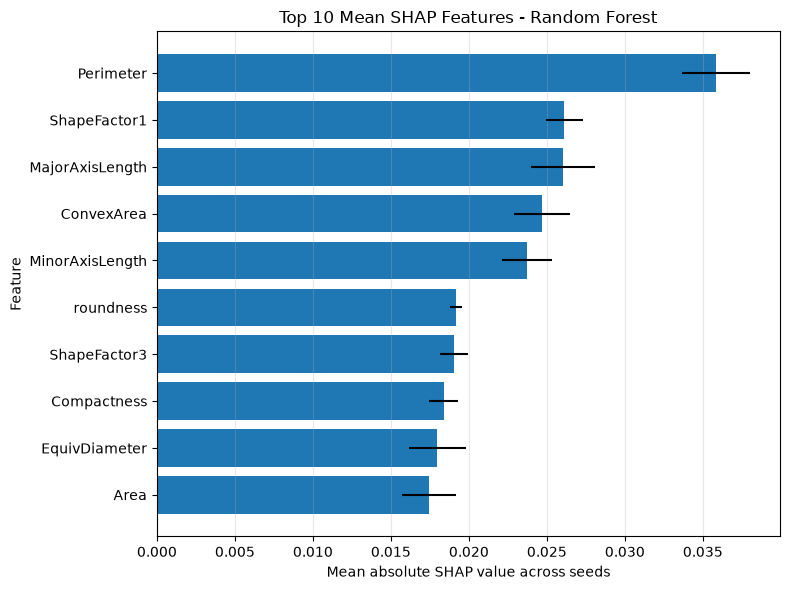

Saved plot: G:\Programming\xai\plots\05_shap_explanations\shap_bar_mean_std_random_forest.png


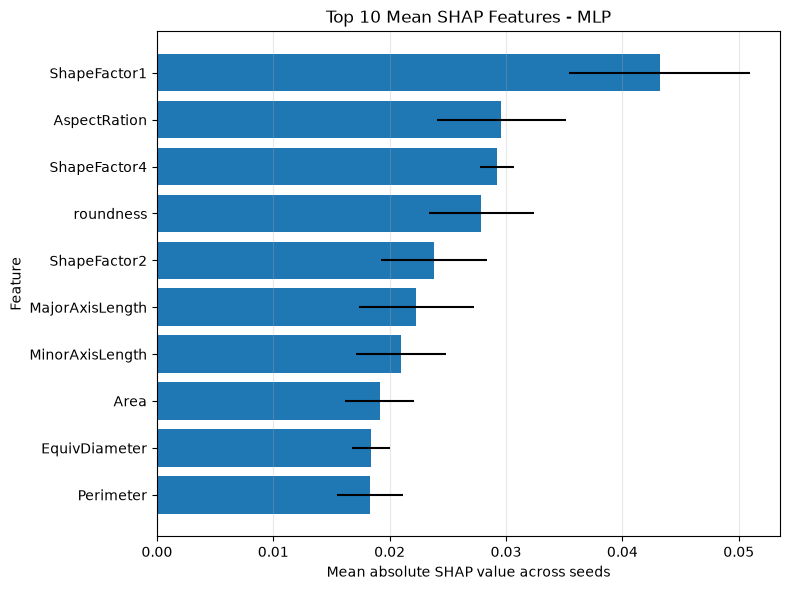

Saved plot: G:\Programming\xai\plots\05_shap_explanations\shap_bar_mean_std_mlp.png


In [20]:
def plot_global_shap_mean_std_bar(
    summary_df: pd.DataFrame,
    model_name: str,
    top_n: int = 10
):
    model_df = summary_df[summary_df["model_name"] == model_name].copy()

    if model_df.empty:
        print(f"No summary data for {model_name}. Skipping plot.")
        return None

    plot_df = (
        model_df
        .sort_values(["mean_rank_order", "mean_abs_shap_mean"], ascending=[True, False])
        .head(top_n)
        .sort_values("mean_abs_shap_mean", ascending=True)
    )

    display_name = MODEL_DISPLAY_NAMES.get(model_name, model_name)

    plt.figure(figsize=(8, 6))
    plt.barh(
        plot_df["feature"],
        plot_df["mean_abs_shap_mean"],
        xerr=plot_df["mean_abs_shap_std"].fillna(0)
    )
    plt.xlabel("Mean absolute SHAP value across seeds")
    plt.ylabel("Feature")
    plt.title(f"Top {top_n} Mean SHAP Features - {display_name}")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()

    plot_path = PLOTS_DIR / f"shap_bar_mean_std_{model_name}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved plot: {plot_path}")
    return plot_path


for model_name in MODEL_NAMES:
    plot_global_shap_mean_std_bar(
        summary_df=global_shap_summary,
        model_name=model_name,
        top_n=10
    )

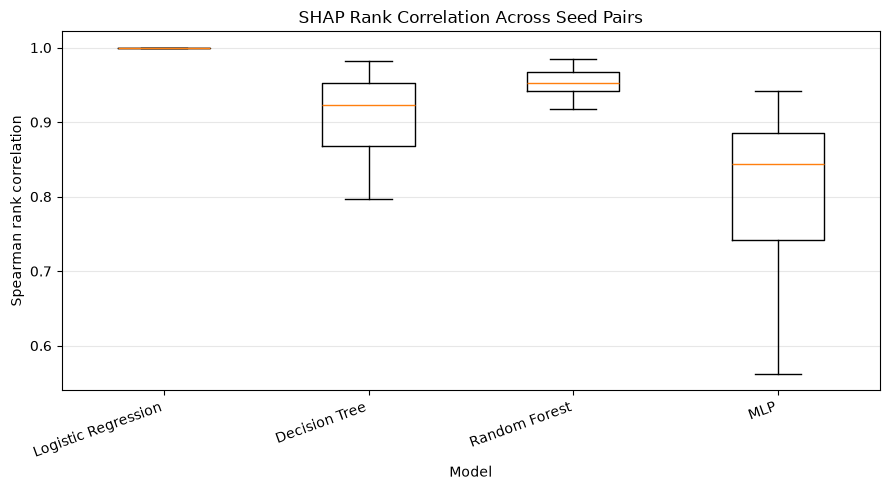

Saved plot: G:\Programming\xai\plots\05_shap_explanations\shap_rank_correlation_across_seed_pairs.png


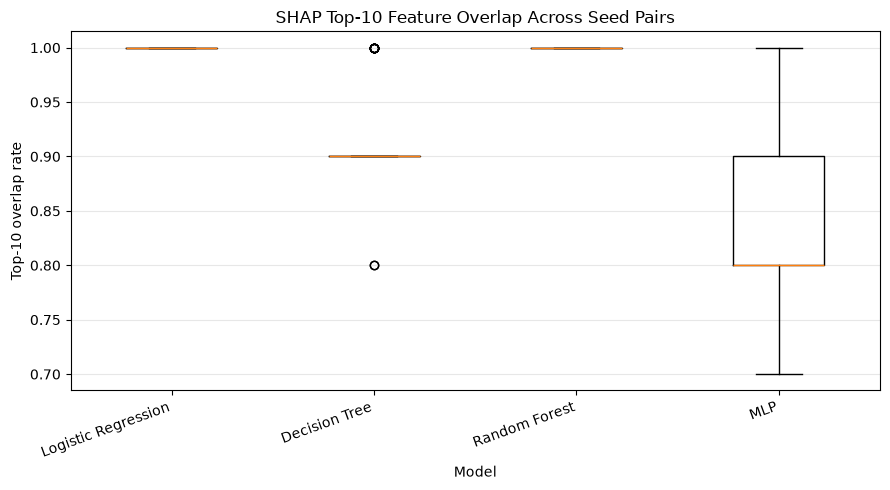

Saved plot: G:\Programming\xai\plots\05_shap_explanations\shap_topk_overlap_across_seed_pairs.png


WindowsPath('G:/Programming/xai/plots/05_shap_explanations/shap_topk_overlap_across_seed_pairs.png')

In [21]:
def plot_boxplot_by_model(
    dataframe: pd.DataFrame,
    value_column: str,
    title: str,
    ylabel: str,
    output_path: Path
):
    data = []
    labels = []

    for model_name in MODEL_NAMES:
        values = dataframe.loc[
            dataframe["model_name"] == model_name,
            value_column
        ].dropna().astype(float).values

        if len(values) > 0:
            data.append(values)
            labels.append(MODEL_DISPLAY_NAMES.get(model_name, model_name))

    if not data:
        print(f"No data available for {value_column}. Skipping plot.")
        return None

    plt.figure(figsize=(9, 5))
    plt.boxplot(data)

    plt.xticks(
        ticks=range(1, len(labels) + 1),
        labels=labels,
        rotation=20,
        ha="right"
    )

    plt.title(title)
    plt.xlabel("Model")
    plt.ylabel(ylabel)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved plot: {output_path}")
    return output_path


plot_boxplot_by_model(
    dataframe=rank_stability_df,
    value_column="spearman_rank_correlation",
    title="SHAP Rank Correlation Across Seed Pairs",
    ylabel="Spearman rank correlation",
    output_path=PLOTS_DIR / "shap_rank_correlation_across_seed_pairs.png"
)

plot_boxplot_by_model(
    dataframe=rank_stability_df,
    value_column="top_k_overlap_rate",
    title=f"SHAP Top-{TOP_K_GLOBAL_STABILITY} Feature Overlap Across Seed Pairs",
    ylabel=f"Top-{TOP_K_GLOBAL_STABILITY} overlap rate",
    output_path=PLOTS_DIR / "shap_topk_overlap_across_seed_pairs.png"
)

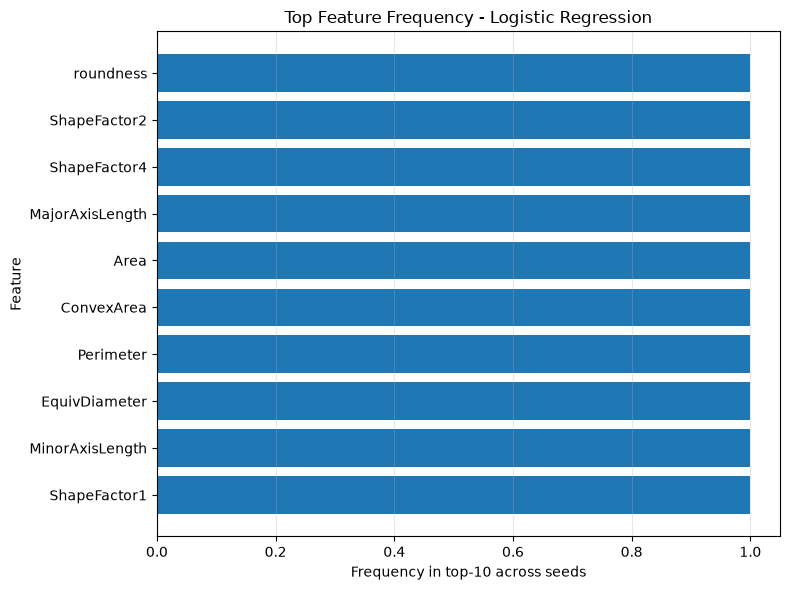

Saved plot: G:\Programming\xai\plots\05_shap_explanations\shap_top_feature_frequency_logistic_regression.png


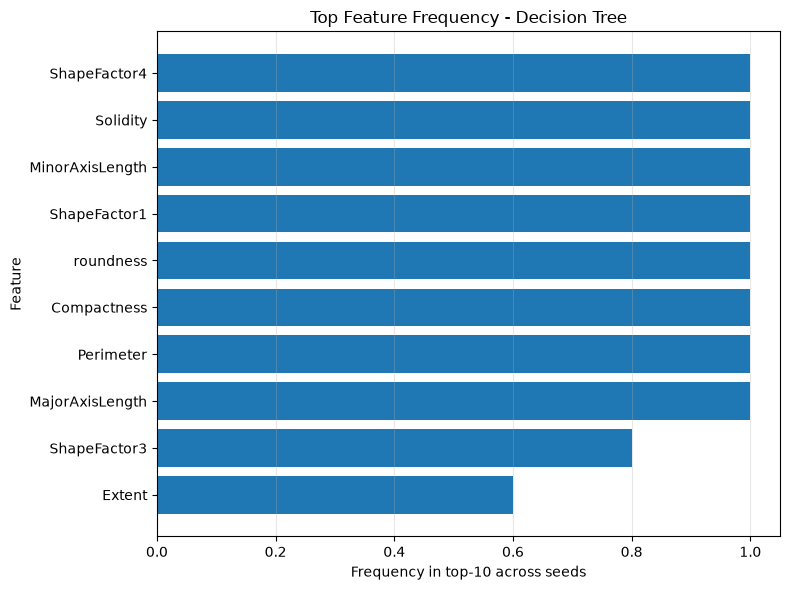

Saved plot: G:\Programming\xai\plots\05_shap_explanations\shap_top_feature_frequency_decision_tree.png


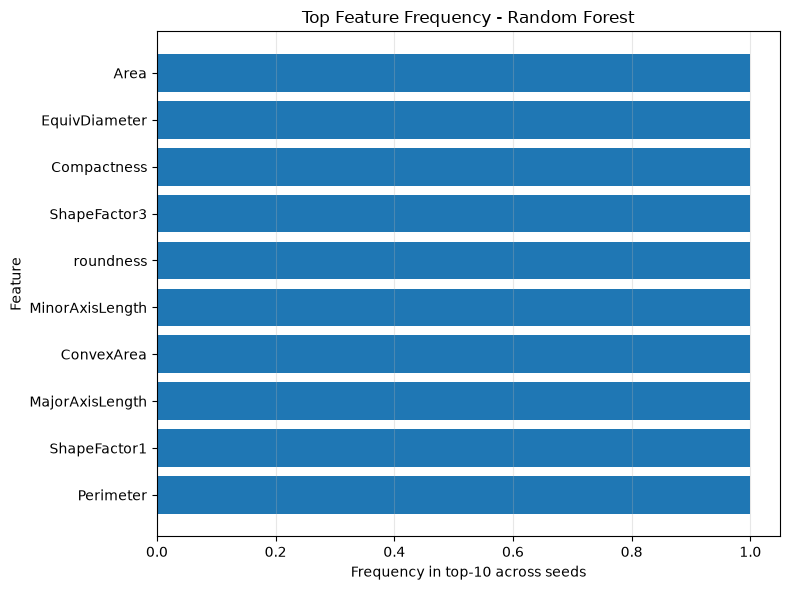

Saved plot: G:\Programming\xai\plots\05_shap_explanations\shap_top_feature_frequency_random_forest.png


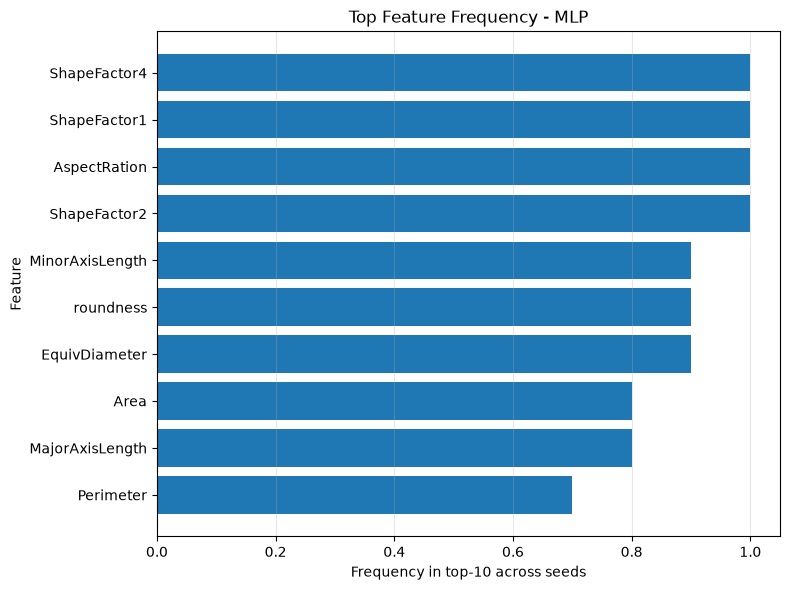

Saved plot: G:\Programming\xai\plots\05_shap_explanations\shap_top_feature_frequency_mlp.png


In [22]:
def plot_top_feature_frequency(
    frequency_df: pd.DataFrame,
    model_name: str,
    top_n: int = 10
):
    model_df = frequency_df[frequency_df["model_name"] == model_name].copy()

    if model_df.empty:
        print(f"No top feature frequency data for {model_name}. Skipping plot.")
        return None

    plot_df = (
        model_df
        .sort_values(["top_k_frequency", "rank_mean"], ascending=[False, True])
        .head(top_n)
        .sort_values("top_k_frequency", ascending=True)
    )

    display_name = MODEL_DISPLAY_NAMES.get(model_name, model_name)

    plt.figure(figsize=(8, 6))
    plt.barh(plot_df["feature"], plot_df["top_k_frequency"])
    plt.xlabel(f"Frequency in top-{TOP_K_GLOBAL_STABILITY} across seeds")
    plt.ylabel("Feature")
    plt.title(f"Top Feature Frequency - {display_name}")
    plt.xlim(0, 1.05)
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()

    plot_path = PLOTS_DIR / f"shap_top_feature_frequency_{model_name}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved plot: {plot_path}")
    return plot_path


for model_name in MODEL_NAMES:
    plot_top_feature_frequency(
        frequency_df=top_feature_frequency_df,
        model_name=model_name,
        top_n=10
    )

## Cell 16: Primary-seed SHAP summary plots

C:\Users\shahr\AppData\Local\Temp\ipykernel_13364\859385475.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


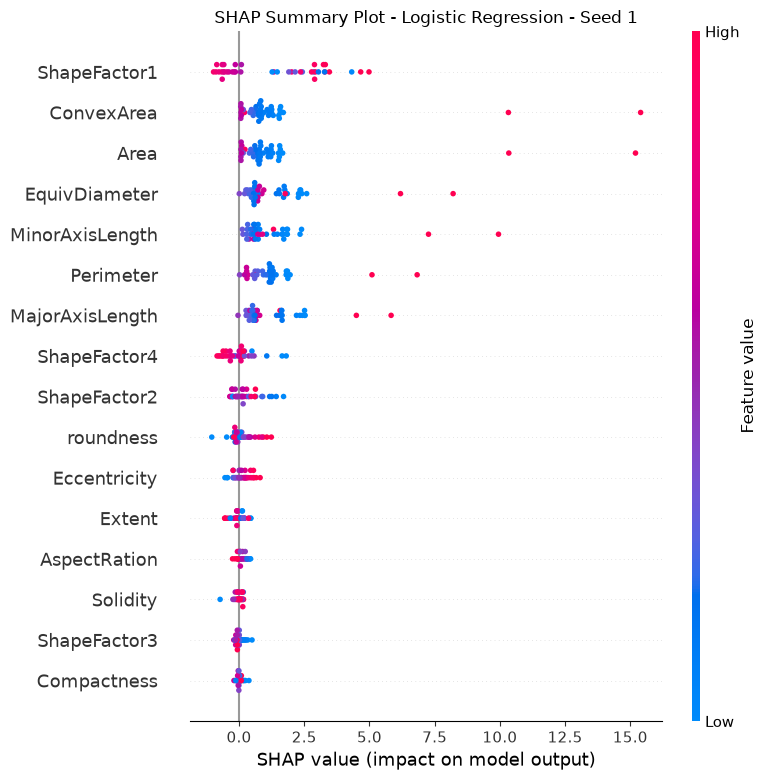

Saved SHAP summary plot: G:\Programming\xai\plots\05_shap_explanations\shap_summary_seed_1_logistic_regression.png


C:\Users\shahr\AppData\Local\Temp\ipykernel_13364\859385475.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


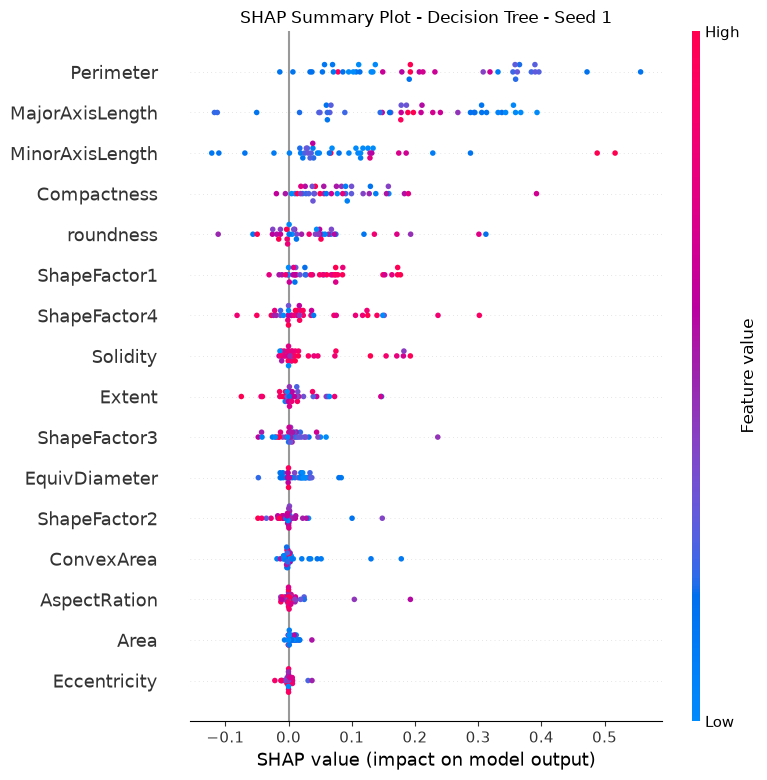

Saved SHAP summary plot: G:\Programming\xai\plots\05_shap_explanations\shap_summary_seed_1_decision_tree.png


C:\Users\shahr\AppData\Local\Temp\ipykernel_13364\859385475.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


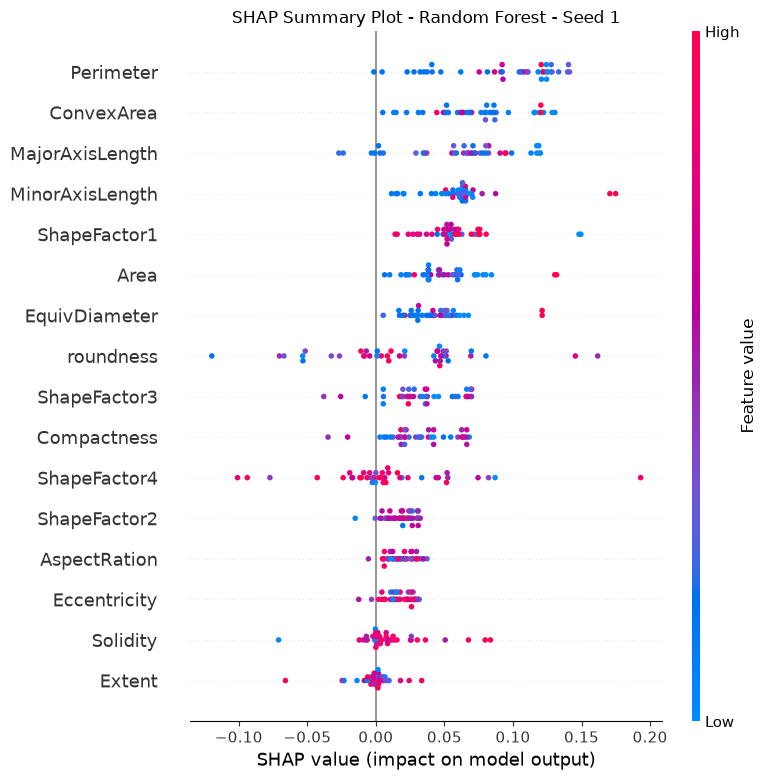

Saved SHAP summary plot: G:\Programming\xai\plots\05_shap_explanations\shap_summary_seed_1_random_forest.png


C:\Users\shahr\AppData\Local\Temp\ipykernel_13364\859385475.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


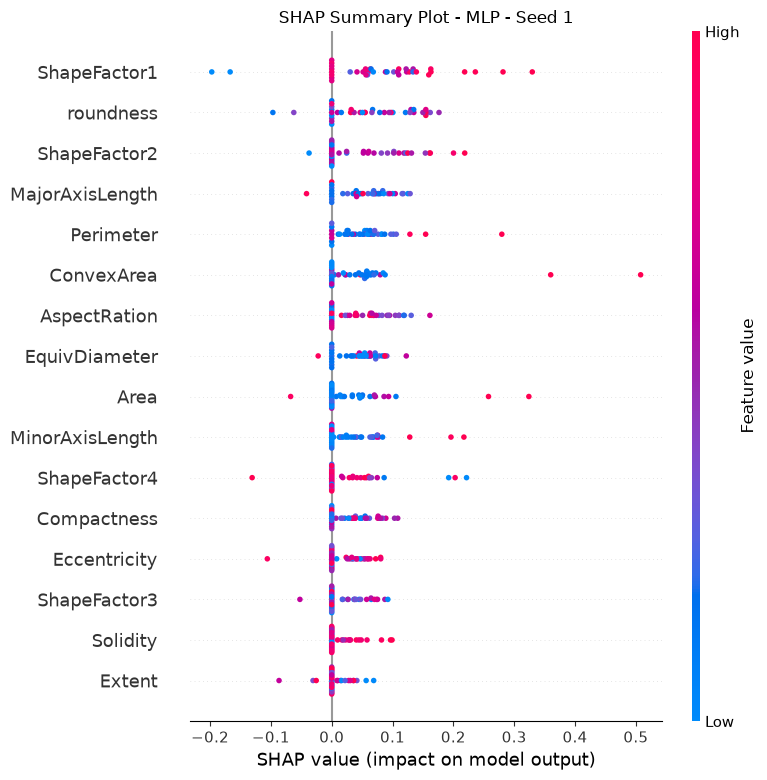

Saved SHAP summary plot: G:\Programming\xai\plots\05_shap_explanations\shap_summary_seed_1_mlp.png


In [23]:
def plot_shap_summary_for_primary_seed(model_name: str, shap_result: dict):
    shap_values = shap_result["shap_values"]
    predicted_labels = shap_result["predicted_labels"]
    X_explain_model = model_input_data[model_name]["X_explain"]

    class_specific_values = []

    for sample_position, predicted_class_id in enumerate(predicted_labels):
        if shap_values.shape[2] == 1:
            class_specific_values.append(shap_values[sample_position, :, 0])
        else:
            class_specific_values.append(
                shap_values[sample_position, :, int(predicted_class_id)]
            )

    class_specific_values = np.asarray(class_specific_values)

    plt.figure()
    shap.summary_plot(
        class_specific_values,
        X_explain_model,
        feature_names=feature_columns,
        show=False
    )

    display_name = MODEL_DISPLAY_NAMES.get(model_name, model_name)
    plt.title(f"SHAP Summary Plot - {display_name} - Seed {PRIMARY_SEED}")
    plt.tight_layout()

    plot_path = PLOTS_DIR / f"shap_summary_seed_{PRIMARY_SEED}_{model_name}.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved SHAP summary plot: {plot_path}")
    return plot_path


if MAKE_PRIMARY_SEED_SUMMARY_PLOTS:
    for model_name in MODEL_NAMES:
        primary_result = shap_results[(PRIMARY_SEED, model_name)]
        plot_shap_summary_for_primary_seed(
            model_name=model_name,
            shap_result=primary_result
        )
else:
    print("Primary-seed SHAP summary plots disabled.")

## Cell 17: Final seeded SHAP summary

In [24]:
best_stability_row = None
least_stability_row = None

if not rank_stability_summary.empty:
    best_stability_row = rank_stability_summary.iloc[0].to_dict()
    least_stability_row = rank_stability_summary.sort_values(
        "spearman_mean",
        ascending=True
    ).iloc[0].to_dict()

shap_summary = {
    "notebook": NOTEBOOK_NAME,
    "experiment_type": "seeded_shap_explanations_fixed_train_test_split",
    "seeds": SEEDS,
    "primary_seed": PRIMARY_SEED,
    "random_state_for_sample_selection_and_background": RANDOM_STATE,
    "force_recompute_shap": FORCE_RECOMPUTE_SHAP,
    "models_explained": MODEL_NAMES,
    "n_seed_model_runs": len(shap_results),
    "number_of_selected_samples": int(len(selected_samples)),
    "selected_samples_path": RESULTS_DIR / "selected_samples.csv",
    "background_sizes": {
        "tree": SHAP_BACKGROUND_SIZE_TREE,
        "linear": SHAP_BACKGROUND_SIZE_LINEAR,
        "mlp": SHAP_BACKGROUND_SIZE_MLP
    },
    "mlp_kernel_nsamples": MLP_KERNEL_NSAMPLES,
    "top_k_local_features": TOP_K_LOCAL_FEATURES,
    "top_k_global_stability": TOP_K_GLOBAL_STABILITY,
    "model_input_types": MODEL_INPUT_TYPES,
    "model_explainer_types": MODEL_EXPLAINER_TYPES,
    "best_global_shap_stability_model_by_spearman": best_stability_row,
    "least_global_shap_stability_model_by_spearman": least_stability_row,
    "saved_outputs": {
        "selected_samples": RESULTS_DIR / "selected_samples.csv",
        "global_feature_importance_all_seeds": global_all_seeds_path,
        "global_feature_importance_mean_std": global_summary_path,
        "global_rank_stability_pairwise": rank_stability_path,
        "global_rank_stability_summary": rank_stability_summary_path,
        "top_feature_frequency": top_feature_frequency_path,
        "local_explanations_all_seeds": local_all_seeds_path,
        "primary_seed_global_compatibility": primary_global_path,
        "primary_seed_local_compatibility": primary_local_path,
        "per_seed_directories": [
            RESULTS_DIR / f"seed_{seed}"
            for seed in SEEDS
        ],
        "plots_directory": PLOTS_DIR
    },
    "notes": [
        "The same selected test samples are explained for all seeds and models.",
        "Samples are selected from primary seed predictions only.",
        "Global SHAP stability is measured using feature-rank Spearman correlation and top-k overlap across seed pairs."
    ]
}

summary_path = RESULTS_DIR / "shap_summary_seeded.json"
legacy_summary_path = RESULTS_DIR / "shap_summary.json"

save_json(shap_summary, summary_path)
save_json(shap_summary, legacy_summary_path)

print(f"Saved seeded SHAP summary: {summary_path}")
print(f"Saved compatibility SHAP summary: {legacy_summary_path}")

print("\nMain output files:")
for label, path in shap_summary["saved_outputs"].items():
    if isinstance(path, list):
        print(f"- {label}: {len(path)} items")
    else:
        print(f"- {label}: {path}")

Saved seeded SHAP summary: G:\Programming\xai\results\05_shap_explanations\shap_summary_seeded.json
Saved compatibility SHAP summary: G:\Programming\xai\results\05_shap_explanations\shap_summary.json

Main output files:
- selected_samples: G:\Programming\xai\results\05_shap_explanations\selected_samples.csv
- global_feature_importance_all_seeds: G:\Programming\xai\results\05_shap_explanations\shap_feature_importance_all_seeds.csv
- global_feature_importance_mean_std: G:\Programming\xai\results\05_shap_explanations\shap_feature_importance_mean_std_across_seeds.csv
- global_rank_stability_pairwise: G:\Programming\xai\results\05_shap_explanations\shap_global_rank_stability_across_seeds.csv
- global_rank_stability_summary: G:\Programming\xai\results\05_shap_explanations\shap_global_rank_stability_summary.csv
- top_feature_frequency: G:\Programming\xai\results\05_shap_explanations\shap_top_feature_frequency_across_seeds.csv
- local_explanations_all_seeds: G:\Programming\xai\results\05_shap_